In [1]:
from constants import DATA_ROOT_PATH_NAME, BANDPASS, HAMPEL_WINDOW_SIZE, HAMPEL_N_SIGMA, LOCAL_DETREND_WINDOW_SEC, LOCAL_DETREND_STEP_SEC, ASR_CUTOFF, ASR_BLOCKSIZE, ASR_WIN_LEN, ASR_WIN_OVERLAP, ASR_MAX_DROPOUT_FRACTION, ASR_MIN_CLEAN_FRACTION, ASR_MAX_BAD_CHANS

from preprocessing.step.bandpass import BandpassFilterStep
from preprocessing.step.detrend import LocalDetrendStep
from preprocessing.step.hampel import HampelFilterStep
from preprocessing.step.asr import ASRStep
from preprocessing.step.crop import CropStep

from preprocessing.pipeline import PreprocessingPipeline

from features.factory import CompleteFeatureExtractionEngine, FeatureExtractionConfig, CompleteFeatureExtractionResult
from features.categories import FeatureCategory
from features.dataset import SingleParticipantProcessedFeatureDatasetFactory, SingleParticipantProcessedFeatureDataset, FeaturesDataset
from features.io import FeaturesDatasetIO, SingleParticipantProcessedFeatureDatasetIO

from eeg.data import EEGRecordedDataProvider, EEGRecordedDataHelper

from features.name import FeatureNameHelper



%load_ext autoreload
%autoreload 2

# Création des 2 datasets de features

In [2]:
recordings = EEGRecordedDataProvider.build(DATA_ROOT_PATH_NAME, load_data=False)

/mnt/ssd2/pth-eeg/eeg/eeg/data.py:292: RuntimeWarning: Did not find any events.tsv associated with sub-001_task-eyesclosed.

The search_str was "data/sub-001/**/eeg/sub-001*events.tsv"
  raw_preview: mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:292: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 57
Group: A
MMSE: 16
  raw_preview: mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:292: RuntimeWarning: Did not find any events.tsv associated with sub-002_task-eyesclosed.

The search_str was "data/sub-002/**/eeg/sub-002*events.tsv"
  raw_preview: mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:292: RuntimeWarning: Unable to map the following column(s) to to MNE:
Gender: F
Age: 78
Group: A
MMSE: 22
  raw_preview: mne.io.Raw = read_raw_bids(bids_path=bids_path, verbose=False)
/mnt/ssd2/pth-eeg/eeg/eeg/data.py:292:

In [23]:
tagged_recordings = EEGRecordedDataHelper.tag(recordings)

NameError: name 'recordings' is not defined

In [4]:
asr_pipeline = PreprocessingPipeline(name="ASR",
                                        steps=[
                                                BandpassFilterStep(BANDPASS),
                                                ASRStep(cutoff=ASR_CUTOFF, blocksize=ASR_BLOCKSIZE, win_len=ASR_WIN_LEN, win_overlap=ASR_WIN_OVERLAP, max_dropout_fraction=ASR_MAX_DROPOUT_FRACTION, min_clean_fraction=ASR_MIN_CLEAN_FRACTION, max_bad_chans=ASR_MAX_BAD_CHANS)
                                                ])

dethamp_pipeline = PreprocessingPipeline(name="det-hamp",
                                        steps=[ 
                                                BandpassFilterStep(BANDPASS),
                                                LocalDetrendStep(window_sec=LOCAL_DETREND_WINDOW_SEC, step_sec=LOCAL_DETREND_STEP_SEC),
                                                HampelFilterStep(window_size=HAMPEL_WINDOW_SIZE, n_sigma=HAMPEL_N_SIGMA)
                                                ])

In [5]:
categories_to_extract = [FeatureCategory.WAVELET, FeatureCategory.TEMPORAL, FeatureCategory.POWER_RATIO, FeatureCategory.SPECTRAL]
config = FeatureExtractionConfig(categories_to_extract=categories_to_extract)
feature_extraction_engine = CompleteFeatureExtractionEngine(config=config)

In [64]:
extraction_results= []
for eeg in tagged_recordings:
    # calibration une seule fois sur l'enregistrement source
    dethamp_pipeline.prepare(eeg)
    asr_pipeline.prepare(eeg)

    for window in EEGRecordedDataHelper.iter_split(eeg, t_start=10, window_seconds=60):
        dethamp_processed = dethamp_pipeline.compute(window, unload_source=True, prepare_steps=False)
        dethamp_extraction_result = feature_extraction_engine.extract(dethamp_processed)
        detamp_single_participant_dataset = SingleParticipantProcessedFeatureDatasetFactory.build(dethamp_extraction_result)
        SingleParticipantProcessedFeatureDatasetIO.export(detamp_single_participant_dataset, "computed_data/dethamp")
        dethamp_processed.unload()

        asr_processed = asr_pipeline.compute(window, unload_source=True, prepare_steps=False)
        asr_extraction_result = feature_extraction_engine.extract(asr_processed)
        asr_single_participant_dataset = SingleParticipantProcessedFeatureDatasetFactory.build(asr_extraction_result)
        SingleParticipantProcessedFeatureDatasetIO.export(asr_single_participant_dataset, "computed_data/asr")
        asr_processed.unload()

    dethamp_pipeline.clear_caches()
    asr_pipeline.clear_caches()

NameError: name 'tagged_recordings' is not defined

# Import de toutes les features de tous les participants

In [2]:
dethamp_dataset = FeaturesDatasetIO.load("computed_data/dethamp")
dethamp_dataset = dethamp_dataset.selector.filter_by_healthstate(["AD", "CN"])

asr_dataset = FeaturesDatasetIO.load("computed_data/asr")
asr_dataset = asr_dataset.selector.filter_by_healthstate(["AD", "CN"])

# Tests statistiques

In [3]:
from stats.queries.factory import QueryFactoryConfig, QueryFactory, CorrectionSpec

factory = QueryFactory(
    QueryFactoryConfig.from_lists(
        subject_variables={"subject_age", "subject_mmse", "subject_id", "subject_health", "subject_gender"},
        ppc_bands=dethamp_dataset.ppc_band_names,
        psd_bands=dethamp_dataset.psd_band_names,
        eeg_features=dethamp_dataset.feature_names,
    )
)

fdr_correction = CorrectionSpec(
    method="fdr_bh",
    alpha=0.05,
)

In [31]:
from stats.runner import StatisticalTestRunner

queries = {feature_name : factory.compare(
    target=feature_name,
    group_a="Alzheimer",
    group_b="Healthy",
    correction=fdr_correction) for feature_name in dethamp_dataset.scalar_feature_names}


outcomes = StatisticalTestRunner.run(queries, asr_dataset)


# Entrainement d'un arbre de décision

In [3]:
from features.dataset import FeaturesDatasetSelector
from prediction.decision_tree_2.base import DecisionTree, DecisionTreeParameters
from prediction.decision_tree_2.score import DecisionTreeScoreEngine
from prediction.decision_tree_2.tunning import HyperparameterGrid, DecisionTreeOptimizer


TARGET = "subject_health"

METADATA_COLUMNS = [
    "subject_id",
    "subject_group",
    "subject_gender",
    "subject_age",
    "subject_mmse",
]

feature_name_factory = FeatureNameHelper(dethamp_dataset.all_feature_names)

feature_family_names = [
    "theta_alpha_ratio",
    "theta_beta_ratio",
    "gamma_alpha_ratio",
    "spectral_power_ratio",
    "spectral_centroid",
    "spectral_spread",
    "spectral_flux",
    "spectral_rolloff",
    "alpha_dominant_frequency",
    "gamma_dominant_frequency",
    "relative_wavelet_energy",
    "relative_wavelet_packet_energy",
    "alpha",
    "beta",
    "gamma"
]



dataset = FeaturesDatasetSelector.select(dethamp_dataset, feature_family_names=feature_family_names)
score_engine = DecisionTreeScoreEngine()

In [4]:
hyperparamter_grid = HyperparameterGrid()
hyperparamter_searcher = DecisionTreeOptimizer(dataset=dataset, score_engine=score_engine)

#optimized_decision_tree, best_scoring = hyperparamter_searcher.optimize(hyperparamter_grid, lambda_std = 0)
optimized_decision_tree = DecisionTree(parameters=DecisionTreeParameters(criterion='gini', max_depth=5, min_samples_split=2, min_samples_leaf=10))

In [8]:
from prediction.decision_tree_2.feature_selection import FeatureForwardSelectionEngine, DecisionTreeFeatureSelectionTrainer

decision_tree_trainer = DecisionTreeFeatureSelectionTrainer(score_engine)
trained_tree, test_dataset = decision_tree_trainer.train(optimized_decision_tree, dataset)

In [9]:
scoring = score_engine.evaluate_trained_tree(trained_tree, test_dataset)
scoring.report()


🌳 DECISION TREE – FINAL TEST REPORT

📊 Global metrics
--------------------------------------------------
Accuracy          : 0.7500
Balanced accuracy : 0.7433

📊 Recall by class
--------------------------------------------------
             recall
Alzheimer  0.811881
Healthy    0.674699

📊 Precision by class
--------------------------------------------------
           precision
Alzheimer   0.752294
Healthy     0.746667

📊 F1-score by class
--------------------------------------------------
                 f1
Alzheimer  0.780952
Healthy    0.708861

📊 Confusion matrix
--------------------------------------------------
pred       Alzheimer   Healthy
true                          
Alzheimer   0.811881  0.188119
Healthy     0.325301  0.674699




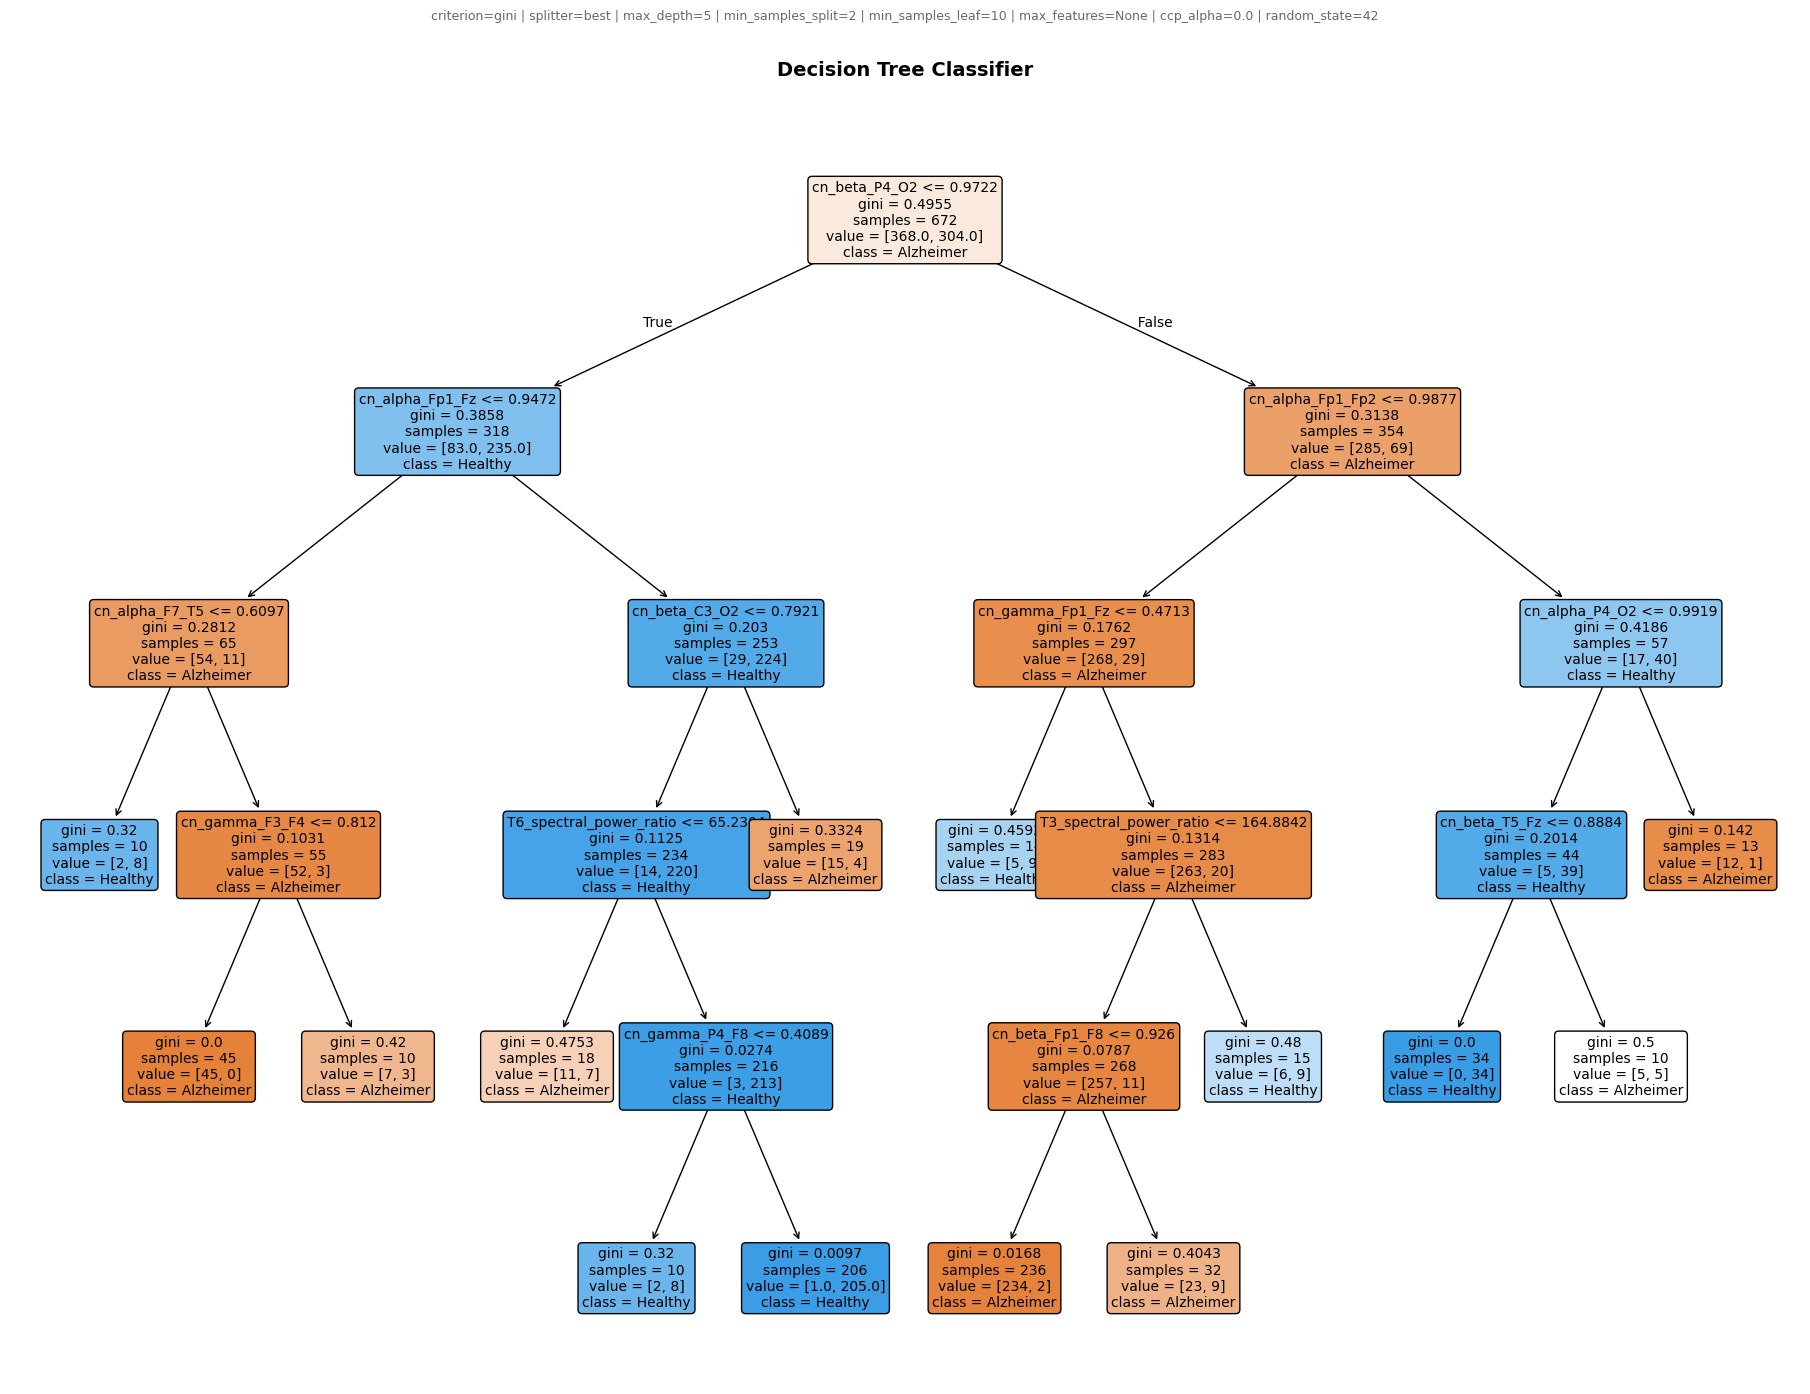

In [10]:
from prediction.decision_tree_2.plot import DecisionTreeVisualizationEngine
DecisionTreeVisualizationEngine.plot(trained_tree, precision=4)

In [8]:
from prediction.decision_tree_2.analysis import DecisionTreeAnalysisEngine
analyzer = DecisionTreeAnalysisEngine(trained_tree)


nodes_analysis = analyzer.node_analysis()
rules_analysis = analyzer.leaf_rule_analysis()
splits_analysis = analyzer.internal_split_analysis()
features_analysis = analyzer.feature_importance_analysis()
eeg_structure_analysis = analyzer.eeg_structure_analysis()

In [22]:
rules_analysis.to_dataframe()

,node_id,predicted_class,support,confidence,strength,impurity_value,class_probas,rule
0,19,Alzheimer,236,0.991525,5.421721,0.016806,"{'Alzheimer': 0.9915254237288136, 'Healthy': 0...",cn_beta_P4_O2 > 0.972173 AND cn_alpha_Fp1_Fp2 ...
1,12,Healthy,206,0.995146,5.306832,0.009662,"{'Alzheimer': 0.0048543689320388345, 'Healthy'...",cn_beta_P4_O2 <= 0.972173 AND cn_alpha_Fp1_Fz ...
2,5,Alzheimer,45,1.000000,3.828641,0.000000,"{'Alzheimer': 1.0, 'Healthy': 0.0}",cn_beta_P4_O2 <= 0.972173 AND cn_alpha_Fp1_Fz ...
3,24,Healthy,34,1.000000,3.555348,0.000000,"{'Alzheimer': 0.0, 'Healthy': 1.0}",cn_beta_P4_O2 > 0.972173 AND cn_alpha_Fp1_Fp2 ...
4,20,Alzheimer,32,0.718750,2.513115,0.404297,"{'Alzheimer': 0.71875, 'Healthy': 0.28125}",cn_beta_P4_O2 > 0.972173 AND cn_alpha_Fp1_Fp2 ...
5,26,Alzheimer,13,0.923077,2.436053,0.142012,"{'Alzheimer': 0.9230769230769231, 'Healthy': 0...",cn_beta_P4_O2 > 0.972173 AND cn_alpha_Fp1_Fp2 ...
6,13,Alzheimer,19,0.789474,2.365052,0.332410,"{'Alzheimer': 0.7894736842105263, 'Healthy': 0...",cn_beta_P4_O2 <= 0.972173 AND cn_alpha_Fp1_Fz ...
7,3,Healthy,10,0.800000,1.918316,0.320000,"{'Alzheimer': 0.2, 'Healthy': 0.8}",cn_beta_P4_O2 <= 0.972173 AND cn_alpha_Fp1_Fz ...
8,11,Healthy,10,0.800000,1.918316,0.320000,"{'Alzheimer': 0.2, 'Healthy': 0.8}",cn_beta_P4_O2 <= 0.972173 AND cn_alpha_Fp1_Fz ...
9,9,Alzheimer,18,0.611111,1.799379,0.475309,"{'Alzheimer': 0.6111111111111112, 'Healthy': 0...",cn_beta_P4_O2 <= 0.972173 AND cn_alpha_Fp1_Fz ...
